>
> # MaaSSim tutorial

 ### quickstart

In [1]:
%load_ext autoreload
%autoreload 2
import os, sys # add MaaSSim to path (not needed if MaaSSim is already in path)
module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)
    
import MaaSSim

prepare

In [2]:
from MaaSSim.utils import get_config, load_G, prep_supply_and_demand, generate_demandX, generate_vehiclesX, initialize_df  # simulator
from MaaSSim.data_structures import structures as inData
from MaaSSim.simulators import simulate
from MaaSSim.visualizations import plot_veh
import logging

In [3]:
import pandas as pd

In [4]:
import ExMAS

In [5]:
params = get_config('../../data/config/delft.json')  # load configuration

In [6]:
params.times.pickup_patience = 3600 # 1 hour of simulation
params.simTime = 4 # 1 hour of simulation
params.nP = 500 # reuqests (and passengers)
params.nV = 100 # vehicles

In [7]:
params = MaaSSim.utils.get_config('glance.json')
params.city = "Delft, Netherlands"
params.paths.G = "../../data/graphs/Delft.graphml"
params.paths.skim = "../../data/graphs/Delft.csv"

params.vehicle_fixed_positions = True
params.times.pickup_patience = 3600
params.dist_threshold = 20000 #meter
params.dist_threshold_min = 3000 #meter

params.d2d.probabilistic = True
params.d2d.heterogeneous = False
params.proportional_std = 0.1 # proportional standard deviation [0.1, 0.2, 0.3] for both VoT & RW distributions
params.d2d.ini_att = 0.01
params.d2d.B_income = 1

params.d2d.B_inveh_time = 1
params.d2d.B_exp_time = 2 #1.5 in Oded's paper
params.PT_fare = 1 ## euro
params.PT_avg_speed = 6

params.nPM = 1 # number of platforms. platform id starts from 1
params.platforms.base_fare = 1.4 #euro 
params.platforms.fare = float(1.2)# float(1.20) #euro/km #http://taxihowmuch.com/
params.platforms.min_fare = float(4) # euro #http://taxihowmuch.com/
params.d2d.fuel_cost = 0.25 #euro/km #https://help.ubercarshare.com/hc/en-gb/articles/360022882131-Choosing-your-car-s-distance-rate  
params.platforms.comm_rate = float(0.20) # float(0.20) for baseline
params.platforms.discount = float(0.0) 
params.platforms.daily_marketing = False
params.platforms.incentive = float(0.0)

params.d2d.learning_d = 1 
params.d2d.B_Experience = 0.70
params.d2d.B_WOM = 0.20
params.d2d.B_Marketing = 0.10
params.d2d.diffusion_speed = 10/100 
params.d2d.m = 5
params.d2d.Eini_att = 0.01
params.d2d.adj_s = 2
params.VoT = 10.63 # value of time per hour
params.seed = 1
params.f_stop_crit = False
params.assert_me = False
# params.paths.requests = 'Amsterdam_requests.csv'

params.nP = 500
params.nV = 100
params.nD = 1 #7.5 years (July2012-Dec2019) * 12 months * 4 weeks = 360 weeks (days of simulation)
params.simTime = 4 
params.d2d.res_wage = params.simTime*11.16

In [8]:
params.t0 = pd.Timestamp.now()
params.shareability.avg_speed = params.speeds.ride
params.shareability.shared_discount = 0.3
params.shareability.delay_value = 1
params.shareability.WtS = 1.3
params.shareability.price = 1.5 #eur/km
params.shareability.VoT = 0.0035 #eur/s
params.shareability.matching_obj = 'u_pax' #minimize VHT for vehicles
params.shareability.pax_delay = 0
params.shareability.horizon = 600
params.shareability.max_degree = 4
params.shareability.nP = params.nP
params.shareability.share = 1
params.shareability.without_matching = True

In [9]:
inData = load_G(inData, params)  # load network graph 

In [10]:
inData = generate_demandX(inData, params, avg_speed = False)
inData.vehicles = generate_vehiclesX(inData, params, params.nV)
inData.vehicles.platform = inData.vehicles.apply(lambda x: 0, axis = 1)
inData.passengers.platforms = inData.passengers.apply(lambda x: [0], axis = 1)
inData.requests['platform'] = inData.requests.apply(lambda row: 1, axis = 1) 
inData.platforms = initialize_df(inData.platforms)
inData.platforms.loc[0]=[1,'Uber',30]
params.shareability.share = 1
params.shareability.without_matching = True

In [11]:
inData = ExMAS.main(inData, params.shareability, plot=False) # create shareability graph (ExMAS) 

11-03-25 13:30:44-INFO-Initializing pairwise trip shareability between 500 and 500 trips.
11-03-25 13:30:44-INFO-creating combinations
11-03-25 13:30:44-INFO-249500	 nR*(nR-1)
11-03-25 13:30:49-INFO-Reduction of feasible pairs by 99.60%
11-03-25 13:30:49-INFO-Degree 2 	Completed
11-03-25 13:30:49-INFO-trips to extend at degree 2 : 4374
11-03-25 13:30:55-INFO-At degree 2 feasible extensions found out of 2633 searched
11-03-25 13:30:55-INFO-Degree 3 	Completed
11-03-25 13:30:55-INFO-trips to extend at degree 3 : 2633
11-03-25 13:30:59-INFO-At degree 3 feasible extensions found out of 654 searched
11-03-25 13:30:59-INFO-Degree 4 	Completed
11-03-25 13:30:59-INFO-Max degree reached 4
11-03-25 13:30:59-INFO-Trips still possible to extend at degree 4 : 654


In [12]:
inData.platforms

,fare,name,batch_time
id,,,
0,1,Uber,30


simulate

In [13]:
sim = simulate(params = params, inData = inData, logger_level = logging.WARNING) # simulate

11-03-25 13:31:10-INFO-Matching 500 trips to 8161 rides in order to minimize u_pax
11-03-25 13:31:13-INFO-Problem solution: Optimal. 
Total costs for single trips:          3,764 
reduced by matching to:                3,274
11-03-25 13:31:14-WARNING-Setting up 4h simulation at 2025-03-11 11:30:51 for 100 vehicles and 500 passengers in Delft, Netherlands
Day =  0


KeyError: 1

<AxesSubplot:>

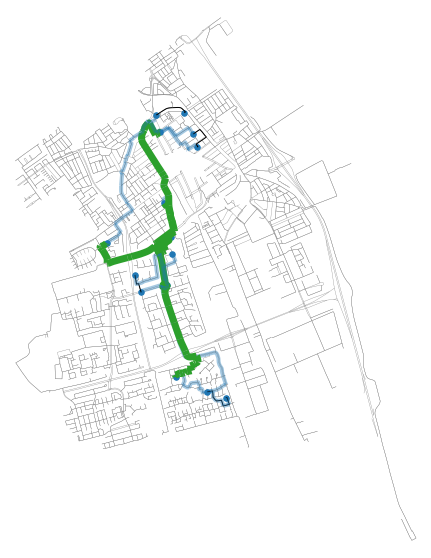

In [14]:
df = sim.runs[0].rides

for i in range(params.nV):
    paxes = df[df.veh==i].paxes
    if paxes.apply(lambda x: len(x)).max()>1:
        break
plot_veh(inData.G, df[df.veh ==19], lw = 1)

In [14]:
params.shareability.share = 0
sim2 = simulate(params = params, inData = inData, logger_level = logging.WARNING) # simulate

07-03-25 09:53:56-WARNING-Setting up 4h simulation at 2025-03-07 07:53:28 for 100 vehicles and 500 passengers in Delft, Netherlands
07-03-25 09:54:09-WARNING-simulation time 11.6 s
07-03-25 09:54:10-WARNING-assertion tests for simulation results - passed


<AxesSubplot:>

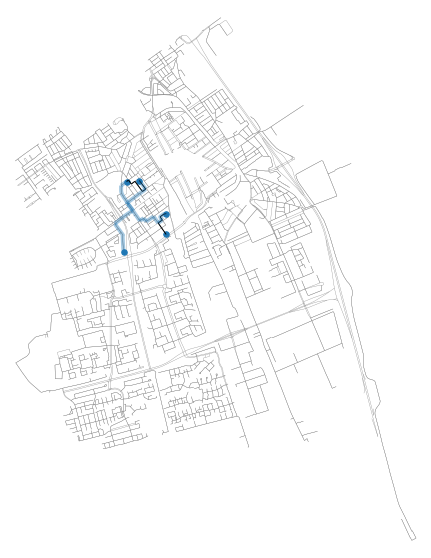

In [15]:
df = sim2.runs[0].rides

for i in range(params.nV):
    paxes = df[df.veh==i].paxes
    if paxes.apply(lambda x: len(x)).max()==1:
        break
plot_veh(inData.G, df[df.veh ==8], lw = 1)

-----